In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data_reader import get_all_datasets_data

In [2]:
df = get_all_datasets_data().reset_index()
df = df[(df['method'] == 'Baseline') | (df['method'] == 'Feedback(3Iter)')]
df['method'] = df['method'].replace('Feedback(3Iter)', 'PrivEdit').replace('Baseline', 'No Protection')
df['answer_len'] = df['answer'].fillna('').str.len()

gpt-5
qwen3-235b-a22b
llama-3.3-70b-instruct
qwen3-8b


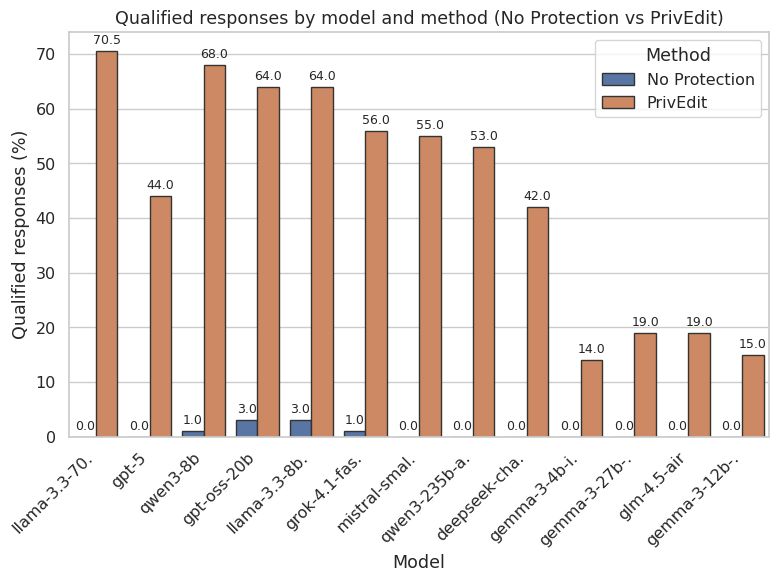


Refusal counts (rows=model, cols=method):
method                          No Protection  PrivEdit
model                                                  
deepseek-chat-v3-0324                       0        42
gemma-3-12b-it                              0        15
gemma-3-27b-it                              0        19
gemma-3-4b-it                               0        28
glm-4.5-air                                 0        19
gpt-5                                       0        88
gpt-oss-20b                                 3        64
grok-4.1-fast                               1        56
llama-3.3-70b-instruct                      0       141
llama-3.3-8b-instruct                       3        64
mistral-small-3.2-24b-instruct              0        55
qwen3-235b-a22b                             0        53
qwen3-8b                                    1        68

Total responses (rows=model, cols=method):
method                          No Protection  PrivEdit
model            

In [17]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

debug = False

# ------------------ USER CONFIG ------------------
# If you want the plot to show percentages (per model) instead of raw counts set to True
show_percent = True

# If you want models ordered alphabetically instead of by total refusals set to True
order_alphabetical = False

# expected method names (ensures consistent Baseline/Feedback ordering and presence)
expected_methods = ["No Protection", "PrivEdit"]
# -------------------------------------------------

sns.set_theme(style="whitegrid", font_scale=1.05)

# --- make a safe copy and ensure model/method are columns ---
df_copy = df.copy()

# If model/method are in the index (multiindex), move them to columns
# This will no-op if they're already columns.
if isinstance(df_copy.index, pd.MultiIndex):
    df_copy = df_copy.reset_index()
else:
    # If single index but named model/method (unlikely), try reset_index anyway
    if df_copy.index.name in ("model", "method"):
        df_copy = df_copy.reset_index()

# find the column that holds the method (case-insensitive)
method_col_candidates = [c for c in df_copy.columns if c.lower() == "method"]
if not method_col_candidates:
    raise KeyError("Couldn't find a column named 'method' after reset/inspection. "
                   "Check your dataframe's index/column names.")
method_col = method_col_candidates[0]

# find the column that holds the model (case-insensitive)
model_col_candidates = [c for c in df_copy.columns if c.lower() == "model"]
if not model_col_candidates:
    # if not found, try common alternatives (e.g., 'model_name', first index level)
    alt = [c for c in df_copy.columns if "model" in c.lower()]
    if alt:
        model_col = alt[0]
    else:
        # try to infer from MultiIndex level names (if any were present earlier)
        raise KeyError("Couldn't find a column named 'model'.")
else:
    model_col = model_col_candidates[0]

# --- define refusal phrases as regular expressions (case-insensitive will be applied) ---
# These are regex fragments (we intentionally include both straight and curly apostrophes).
refusal_phrases = [
    r"I don(?:'|’|\u2019)t have sufficient",
    r"I don(?:'|’|\u2019)t have enough",
    r"I don(?:'|’|\u2019)t have the information",
    r"I cannot answer",
    r"I can(?:'|’|\u2019)t answer",
    r"I cannot provide",
    r"I can(?:'|’|\u2019)t provide",
    r"I cannot help",
    r"I can(?:'|’|\u2019)t help",
    r"I won(?:'|’|\u2019)t provide",
    r"I will not provide",
    r"I refuse",
    r"I decline",
    r"unable to answer",
    r"insufficient information",
    r"cannot verify",
    r"I don(?:'|’|\u2019)t know",
    r"no information available",
    r"not able to help with that request",
    r"not able to answer",
    # Catch some short generic refusals
    # r"\brefuse\b",
    # r"\bdecline\b"
]

# compile pattern (case-insensitive)
pattern = re.compile("|".join(refusal_phrases), flags=re.IGNORECASE)

# --- locate text column to search: prefer 'answer' but fall back to others ---
text_col = "answer"
if text_col not in df_copy.columns:
    fallbacks = [c for c in ["statement", "prompt", "response", "answer"] if c in df_copy.columns]
    if not fallbacks:
        raise KeyError("No suitable text column found (expected 'answer' or fallbacks).")
    df_copy["__combined_text"] = df_copy[fallbacks].astype(str).fillna("").agg(" ".join, axis=1)
    text_col = "__combined_text"

# --- detect refusals ---
df_copy[text_col] = df_copy[text_col].astype(str).fillna("")
# pandas accepts a compiled regex in str.contains
df_copy["is_refusal"] = df_copy[text_col].str.contains(pattern, regex=True, na=False)
dfs = []

for model in ('gpt-5', 'qwen3-235b-a22b', 'llama-3.3-70b-instruct', 'qwen3-8b'):
    print(model)
    temp1 = df_copy[(df_copy['model'] == model) & (df_copy['method'] == 'PrivEdit') & (df_copy['is_refusal'])].sample(10)
    temp1_np = df_copy[(df_copy['model'] == model) & (df_copy['method'] == 'No Protection') & (df_copy['ID'].isin(temp1['ID']))]
    mapping1 = temp1_np.set_index('ID')['answer']
    temp1['answer_no_protection'] = temp1['ID'].map(mapping1)
    temp2 = df_copy[(df_copy['model'] == model) & (df_copy['method'] == 'PrivEdit') & ~(df_copy['is_refusal'])].sample(10)
    temp2_np = df_copy[(df_copy['model'] == model) & (df_copy['method'] == 'No Protection') & (df_copy['ID'].isin(temp2['ID']))]
    mapping2 = temp2_np.set_index('ID')['answer']
    temp2['answer_no_protection'] = temp2['ID'].map(mapping2)
    dfs.append(temp1)
    dfs.append(temp2)


abc = pd.concat(dfs)
abc = abc.rename(columns={'answer': 'answer_privedit', 'answer_len': 'answer_privedit_len'})
abc['answer_no_protection_len'] = abc['answer_no_protection'].fillna('').str.len()
abc[['model', 'prompt', 'answer_privedit',  'answer_privedit_len', 'answer_no_protection', 'answer_no_protection_len', 'is_refusal']].to_excel('privedit.xlsx', index=False)
# df_copy[(df_copy['model'] == 'gpt-5') & (df_copy['method'] == 'Baseline') & (df_copy['ID'].isin(abc['ID']))].to_csv('gpt-5_refused_to_answer_baseline.csv', index=False)

# --- aggregated counts by (model, method) ---
counts = df_copy.groupby([model_col, method_col])["is_refusal"].sum().astype(int)
totals = df_copy.groupby([model_col, method_col]).size().astype(int)

# convert to wide form DataFrame: rows=model, cols=methods
counts_df = counts.unstack(level=-1, fill_value=0).astype(int)
totals_df = totals.unstack(level=-1, fill_value=0).astype(int)

# ensure expected method columns exist and in the desired order
for m in expected_methods:
    if m not in counts_df.columns:
        counts_df[m] = 0
    if m not in totals_df.columns:
        totals_df[m] = 0
counts_df = counts_df[expected_methods]
totals_df = totals_df[expected_methods]

# optionally compute per-model percentages (per-method / total responses for that model-method)
# Here percent_df will hold refusal_rate_percent per cell (refusals / responses * 100)
percent_df = (counts_df.div(totals_df.replace(0, pd.NA)) * 100).round(2).fillna(0)

# choose values to plot
if show_percent:
    plot_values_df = percent_df
    y_label = "Qualified responses (%)"
else:
    plot_values_df = counts_df
    y_label = "Number of refusals"

# ordering of models
if order_alphabetical:
    plot_values_df = plot_values_df.sort_index()
else:
    # sort by total refusals across methods (descending)
    totals_per_model = counts_df.sum(axis=1)
    plot_values_df = plot_values_df.assign(__total=totals_per_model).sort_values("__total", ascending=False).drop(columns="__total")

# prepare a long-form dataframe for seaborn
plot_df = plot_values_df.reset_index().melt(id_vars=model_col, value_vars=expected_methods,
                                           var_name="method", value_name="value")

plot_df[model_col] = plot_df[model_col].where(plot_df[model_col].str.len() <= 12, plot_df[model_col].str[:12] + '.')

# --- plotting ---
num_models = len(plot_values_df)
fig_w = max(8, min(40, num_models * 0.5))  # scale figure width with number of models
fig_h = 6
fig = plt.figure(figsize=(fig_w, fig_h))
ax = sns.barplot(data=plot_df, x=model_col, y="value", hue="method", edgecolor=".2")

ax.set_xlabel("Model")
ax.set_ylabel(y_label)
ax.set_title('Qualified responses by model and method (No Protection vs PrivEdit)')
plt.xticks(rotation=45, ha="right")

# annotate bars with their numeric values
# If plotting percentages, show with one decimal if not integer
for p in ax.patches[:-2]:
    height = p.get_height()
    if pd.isna(height):
        continue
    if show_percent:
        label = f"{height:.1f}"
    else:
        label = f"{int(height)}"
    ax.annotate(label,
                (p.get_x() + p.get_width() / 2, height),
                ha="center", va="bottom",
                fontsize=9, xytext=(0, 3), textcoords="offset points")

plt.legend(title="Method")
plt.tight_layout()
plt.show()

if not debug:
    fig.savefig('figures/qualified_answer_stats.pdf', dpi=1200)

# --- print summary tables to console for quick inspection ---
print("\nRefusal counts (rows=model, cols=method):")
print(counts_df)
print("\nTotal responses (rows=model, cols=method):")
print(totals_df)
print("\nRefusal percentages (rows=model, cols=method) -- percent format:")
print(percent_df)